<a href="https://colab.research.google.com/github/Laibarao12/Coin-Sentiment-Analysis/blob/main/Clean_PSTD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATA PREPROCESSING

In [ ]:
import pandas as pd
import numpy as np
import torch
from PIL import Image
from torchvision import transforms
from transformers import AutoTokenizer, AutoModel


In [ ]:
import os

print(os.listdir(path))

In [ ]:
import os
import pandas as pd
import glob

ann_path = path + "/annotations"

files = glob.glob(ann_path + "/*.tsv")

print("Total files:", len(files))
print(files[:3])

In [ ]:
import pandas as pd
import glob

ann_path = "/content/drive/MyDrive/Dataset/annotations"
files = glob.glob(ann_path + "/*.tsv")

df_list = []

for file in files:
    df = pd.read_csv(file, sep="\t")
    df_list.append(df)

final_df = pd.concat(df_list, ignore_index=True)

print(final_df.shape)
final_df.head()

In [ ]:
df = final_df[[
    "tweet_id",
    "image_id",
    "tweet_text",
    "image_path",
    "text_human",
    "image_human"
]]

df = df.dropna()

print(df.shape)
df.head()

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["tweet_text"] = df["tweet_text"].apply(clean_text)

df.head()

In [ ]:
df.to_csv("cleaned_dataset.csv", index=False)

In [ ]:
texts = df["tweet_text"].tolist()

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

tokenizer = AutoTokenizer.from_pretrained("roberta-base")
model = AutoModel.from_pretrained("roberta-base")
model.eval()

In [ ]:
def get_text_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    with torch.no_grad():
        outputs = model(**inputs)

    return outputs.last_hidden_state[:,0,:].squeeze().numpy()

In [ ]:
text_embeddings = []

for i in range(0, len(texts), 32):
    batch = texts[i:i+32]

    for t in batch:
        text_embeddings.append(get_text_embedding(t))

    if i % 500 == 0:
        print("Processed:", i)

In [ ]:
X_text = np.array(text_embeddings)
np.save("text_embeddings.npy", X_text)

print(X_text.shape)

In [ ]:
import torch
import open_clip
from PIL import Image
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="openai"
)

model = model.to(device)
model.eval()

In [ ]:
def load_batch_images(paths):
    images = []

    for p in paths:
        try:
            img = Image.open(p).convert("RGB")
            img = preprocess(img)
            images.append(img)
        except:
            images.append(torch.zeros(3, 224, 224))  # fallback

    return torch.stack(images)

In [ ]:
image_embeddings = []

batch_size = 32
paths = df["image_path"].tolist()

for i in range(0, len(paths), batch_size):
    batch_paths = paths[i:i+batch_size]

    images = load_batch_images(batch_paths).to(device)

    with torch.no_grad():
        emb = model.encode_image(images)

    image_embeddings.append(emb.cpu().numpy())

    if i % 500 == 0:
        print("Processed images:", i)

In [ ]:
X_img = np.vstack(image_embeddings)
np.save("image_embeddings.npy", X_img)

print(X_img.shape)

In [ ]:
print(X_text.shape)
print(X_img.shape)

FUSED LATENT 128-D

In [ ]:
# =========================================================
# MULTIMODAL CONTRASTIVE LEARNING
# Text Embeddings (768)  -> 128
# Image Embeddings (512) -> 128
# =========================================================

# Install if needed
# !pip install torch numpy scikit-learn

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# =========================================================
# 1. LOADING OUR EMBEDDINGS
# =========================================================

# Example:
# X_text shape = (N, 768)
# X_img  shape = (N, 512)

X_text = np.load("/content/text_embeddings.npy")
X_img  = np.load("/content/image_embeddings.npy")

print("Text Shape:", X_text.shape)
print("Image Shape:", X_img.shape)

# =========================================================
# 2. TRAIN TEST SPLIT
# =========================================================

train_text, test_text, train_img, test_img = train_test_split(
    X_text,
    X_img,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# =========================================================
# 3. DATASET CLASS
# =========================================================

class MultimodalDataset(Dataset):

    def __init__(self, text_embeds, img_embeds):

        self.text_embeds = torch.tensor(
            text_embeds,
            dtype=torch.float32
        )

        self.img_embeds = torch.tensor(
            img_embeds,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.text_embeds)

    def __getitem__(self, idx):

        text = self.text_embeds[idx]
        image = self.img_embeds[idx]

        return text, image

# =========================================================
# 4. DATALOADERS
# =========================================================

train_dataset = MultimodalDataset(train_text, train_img)
test_dataset  = MultimodalDataset(test_text, test_img)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    pin_memory=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    pin_memory=True,
    num_workers=2
)

# =========================================================
# 5. DEVICE
# =========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print("Using Device:", device)

# =========================================================
# 6. PROJECTION HEADS
# =========================================================

# Goal:
# 768 -> 128
# 512 -> 128

class TextProjector(nn.Module):

    def __init__(self):

        super(TextProjector, self).__init__()

        self.network = nn.Sequential(

        nn.Linear(768, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.1),

        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),

        nn.Linear(256, 128)
                )

    def forward(self, x):

        x = self.network(x)

        # Normalize embeddings
        x = F.normalize(x, p=2, dim=1)

        return x


class ImageProjector(nn.Module):

    def __init__(self):

        super(ImageProjector, self).__init__()

        self.network = nn.Sequential(


            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            # nn.Dropout(0.2),

            nn.Linear(256, 128)


        )

    def forward(self, x):

        x = self.network(x)

        # Normalize embeddings
        x = F.normalize(x, p=2, dim=1)

        return x

# =========================================================
# 7. CREATE MODELS
# =========================================================

text_model = TextProjector().to(device)
image_model = ImageProjector().to(device)

# =========================================================
# 8. CONTRASTIVE LOSS (INFO-NCE STYLE)
# =========================================================

class ContrastiveLoss(nn.Module):

    def __init__(self, temperature=0.05):

        super(ContrastiveLoss, self).__init__()

        self.temperature = temperature

    def forward(self, text_features, image_features):

        # Similarity matrix
        logits = torch.matmul(
            text_features,
            image_features.T
        )

        logits = logits / self.temperature

        # Correct pairs are diagonal
        labels = torch.arange(
            text_features.shape[0]
        ).to(device)

        # Text -> Image loss
        loss_text = F.cross_entropy(logits, labels)

        # Image -> Text loss
        loss_image = F.cross_entropy(logits.T, labels)

        # Final symmetric loss
        loss = (loss_text + loss_image) / 2

        return loss

criterion = ContrastiveLoss()

# =========================================================
# 9. OPTIMIZER
# =========================================================

optimizer = torch.optim.AdamW(

    list(text_model.parameters()) +
    list(image_model.parameters()),

    lr=1e-4,
    weight_decay=1e-4
)

# =========================================================
# 10. TRAINING LOOP
# =========================================================
scaler = torch.cuda.amp.GradScaler()
epochs = 25

for epoch in range(epochs):

    text_model.train()
    image_model.train()

    total_loss = 0

    for text_batch, image_batch in train_loader:

        # Move to GPU
        text_batch = text_batch.to(device, non_blocking=True)
        image_batch = image_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        # MIXED PRECISION
        with torch.cuda.amp.autocast():

            # Forward pass
            text_proj = text_model(text_batch)
            image_proj = image_model(image_batch)

            # Contrastive loss
            loss = criterion(text_proj, image_proj)

        # Backprop
        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Loss: {avg_loss:.4f}")
    print("-" * 40)
    torch.cuda.empty_cache()

# =========================================================
# 11. EVALUATION
# =========================================================

text_model.eval()
image_model.eval()

test_loss = 0

with torch.no_grad():

    for text_batch, image_batch in test_loader:

        text_batch = text_batch.to(device, non_blocking=True)
        image_batch = image_batch.to(device, non_blocking=True)

        with torch.cuda.amp.autocast():

            text_proj = text_model(text_batch)
            image_proj = image_model(image_batch)

            loss = criterion(text_proj, image_proj)

        test_loss += loss.item()

avg_test_loss = test_loss / len(test_loader)

print("Test Loss:", avg_test_loss)

# =========================================================
# 12. GENERATE FINAL FUSED EMBEDDINGS
# =========================================================

# IMPORTANT:
# These are your FINAL multimodal embeddings
text_model.eval()
image_model.eval()

with torch.no_grad():

    full_text_tensor = torch.tensor(
        X_text,
        dtype=torch.float32
    ).to(device)

    full_img_tensor = torch.tensor(
        X_img,
        dtype=torch.float32
    ).to(device)

    with torch.cuda.amp.autocast():

        text_proj = text_model(full_text_tensor)
        image_proj = image_model(full_img_tensor)

        fused = (text_proj + image_proj) / 2

        fused = F.normalize(fused, p=2, dim=1)

    fused_np = fused.cpu().numpy()

print(fused_np.shape)
# =========================================================
# 13. SAVE FINAL EMBEDDINGS
# =========================================================

np.save("/content/fused_embeddings.npy", fused_np)

print("\nSaved fused embeddings!")

# =========================================================
# 14. OPTIONAL: CHECK SIMILARITY
# =========================================================

# Higher similarity = better alignment

sample_idx = 0

text_vec = text_proj[sample_idx]
img_vec  = image_proj[sample_idx]

similarity = torch.dot(text_vec, img_vec)

print("\nSample Cosine Similarity:")
print(similarity.item())

In [ ]:
# =========================================================
# AVERAGE COSINE SIMILARITY
# =========================================================

similarities = torch.sum(
    text_proj * image_proj,
    dim=1
)

avg_similarity = similarities.mean().item()

print("Average Cosine Similarity:")
print(avg_similarity)

FILTERING NEUTRAL TWEETS

In [ ]:
# =========================================================
# STEP 1: FILTER OUT NEUTRAL/NEWS TWEETS (GPU ACCELERATED)
# =========================================================

# Install if needed
# !pip install transformers tqdm torch

from transformers import pipeline
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
import torch

# 1. Checking for GPU and setting the device
# If a GPU (CUDA) is available, it uses device 0. Otherwise, it uses CPU (-1).
device = 0 if torch.cuda.is_available() else -1
print(f"Using device: {'GPU' if device == 0 else 'CPU'}")

# 2. Load the Emotion AI Brain, TELLING IT TO USE THE GPU
print("Loading Emotion Model...")
classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=1,
    device=device  # <--- THIS IS THE MAGIC WORD FOR GPU!
)
print("Model loaded!")

# 3. Enable the progress bar for pandas
tqdm.pandas()

# 4. Create a function to get the top emotion
def get_top_emotion(text):
    try:
        text = str(text)[:512] # Truncate long tweets
        # Get the top predicted emotion
        prediction = classifier(text)[0][0]
        return prediction['label']
    except:
        return "error"

# 5. Apply the model to your dataframe (This will show a progress bar!)
print("Classifying tweets... Please wait. This will be much faster on GPU!")
df['top_emotion'] = df['tweet_text'].progress_apply(get_top_emotion)

# 6. LOOK AT THE BREAKDOWN
print("\n--- Emotion Breakdown ---")
print(df['top_emotion'].value_counts())

# 7. FILTER! Keep everything that is NOT neutral
df_emotional = df[df['top_emotion'] != 'neutral'].copy()

print(f"\nOriginal dataset size: {len(df)}")
print(f"Emotional dataset size: {len(df_emotional)}")
print(f"We removed {len(df) - len(df_emotional)} news/neutral tweets!")

LOADING

In [ ]:
# =========================================================
# STEP 2: FILTER THE EXISTING EMBEDDINGS
# =========================================================

# 1. Load your original fused embeddings
fused_embeddings = np.load("/content/fused_embeddings.npy")

# 2. Get the index positions of the emotional tweets
# This ensures the embeddings perfectly match the tweets we kept
emotional_indices = df_emotional.index.values

# 3. Slice the embeddings array!
fused_filtered = fused_embeddings[emotional_indices]

print("Original Embeddings Shape:", fused_embeddings.shape)
print("Filtered Embeddings Shape:", fused_filtered.shape)

# 4. Save the filtered embeddings
np.save("/content/fused_embeddings_filtered.npy", fused_filtered)
print("Saved filtered embeddings!")

In [ ]:
from google.colab import files

files.download('/content/fused_embeddings_filtered.npy')

In [ ]:
# =========================================================
# STEP 3: UMAP ON FILTERED DATA
# =========================================================

import umap
import matplotlib.pyplot as plt

print("Running UMAP on emotional tweets only...")
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

embedding_2d_filtered = reducer.fit_transform(fused_filtered)

# VISUALIZE
plt.figure(figsize=(10, 8))
plt.scatter(
    embedding_2d_filtered[:, 0],
    embedding_2d_filtered[:, 1],
    s=5,
    alpha=0.6
)
plt.title("UMAP of FILTERED Emotional Tweets", fontsize=14)
plt.show()

In [ ]:
# =================================================================
# STEP 4: CLUSTER THE FILTERED UMAP & NAME THE EMOTIONS ALSO GMM
# =================================================================

from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

NUM_EMOTIONS = 4 # Let's try 4 to slice that long cluster!

print(f"Running GMM to find {NUM_EMOTIONS} emotional clusters...")
gmm_filtered = GaussianMixture(n_components=NUM_EMOTIONS, random_state=42, n_init=10)
cluster_labels_filtered = gmm_filtered.fit_predict(embedding_2d_filtered)

# Add the cluster labels to our filtered dataframe
df_emotional['cluster'] = cluster_labels_filtered

# VISUALIZE THE NEW CLUSTERS
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embedding_2d_filtered[:, 0],
    embedding_2d_filtered[:, 1],
    c=cluster_labels_filtered,
    s=5,
    alpha=0.6,
    cmap='Set1'
)
plt.title(f"GMM: {NUM_EMOTIONS} Emotion Clusters (Filtered Data)", fontsize=14)
plt.legend(*scatter.legend_elements(), title="Cluster ID")
plt.show()

# =========================================================
# AUTOMATICALLY NAME THE CLUSTERS USING ZERO-SHOT LABELS
# =========================================================

print("\nNaming the clusters based on Zero-Shot Emotion AI...\n")

for cluster_id in range(NUM_EMOTIONS):
    # Get all rows for this cluster
    cluster_data = df_emotional[df_emotional['cluster'] == cluster_id]

    # Find the most common emotion label in this cluster
    top_emotion = cluster_data['top_emotion'].mode()[0]
    emotion_count = len(cluster_data[cluster_data['top_emotion'] == top_emotion])
    total_count = len(cluster_data)
    percentage = (emotion_count / total_count) * 100

    print(f"Cluster {cluster_id} is primarily: {top_emotion.upper()} ({percentage:.1f}% of tweets)")

    # Print 2 sample tweets to prove it
    print("Sample tweets:")
    samples = cluster_data.sample(n=2, random_state=42)
    for idx, row in samples.iterrows():
        print(f"  - [{row['top_emotion']}] {row['tweet_text'][:100]}...")
    print("-" * 60)

Running GMM to find 4 emotional clusters...


NameError: name 'embedding_2d_filtered' is not defined

In [ ]:
for cluster_id in range(NUM_EMOTIONS):
    cluster_data = df_emotional[df_emotional['cluster'] == cluster_id]
    emotion_counts = cluster_data['final_emotion'].value_counts(normalize=True) * 100
    print(f"\nCluster {cluster_id} full breakdown:")
    print(emotion_counts.round(1))

In [ ]:
# =========================================================
# STEP 5: VISUALIZE UMAP USING ZERO-SHOT EMOTION LABELS
# =========================================================

# Install seaborn for better plotting
# !pip install seaborn

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Create a DataFrame with our UMAP coordinates and the Emotion labels
umap_df = pd.DataFrame({
    'UMAP_1': embedding_2d_filtered[:, 0],
    'UMAP_2': embedding_2d_filtered[:, 1],
    'Emotion': df_emotional['top_emotion'].values # Use our zero-shot labels!
})

# 2. Plot it with Seaborn (this automatically creates a legend with emotion names!)
plt.figure(figsize=(12, 10))

# We use 'hue' to color the dots by Emotion!
sns.scatterplot(
    data=umap_df,
    x='UMAP_1',
    y='UMAP_2',
    hue='Emotion',
    palette='deep',      # Bright, distinct colors
    s=8,                 # Dot size
    alpha=0.6,           # Slightly transparent
    linewidth=0          # No border on dots
)

plt.title("True Emotional Landscape of PTSD Tweets", fontsize=16)
plt.legend(title="Detected Emotion", markerscale=3)
plt.show()

In [ ]:
# =========================================================
# FINAL STEP: CREATE YOUR 3-4 DEFINITIVE EMOTION CLUSTERS
# =========================================================

# 1. Let's group the 7 emotions into 3 or 4 core PTSD emotions
# You can change these mappings if you disagree with them!

emotion_mapping = {
    'fear': 'Fear_Anxiety',
    'surprise': 'Fear_Anxiety',  # Surprise in disasters often = shock/fear

    'sadness': 'Sadness_Despair',
    'disgust': 'Sadness_Despair', # Disgust often blends with depressive sadness here

    'anger': 'Anger_Frustration',

    'joy': 'Hope_Relief'         # Joy in disaster contexts is usually relief/gratitude
}

# Apply the mapping to your dataframe
df_emotional['final_emotion'] = df_emotional['top_emotion'].map(emotion_mapping)

# 2. Check the final counts!
print("=== FINAL EMOTION DISTRIBUTION ===")
print(df_emotional['final_emotion'].value_counts())

# 3. VISUALIZE THE FINAL EMOTION MAP
# Even though the math is mixed, let's color it by our FINAL TRUTH labels
umap_df['Final_Emotion'] = df_emotional['final_emotion'].values

plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=umap_df,
    x='UMAP_1',
    y='UMAP_2',
    hue='Final_Emotion',
    palette='Set1',       # Bright, distinct colors for 4 categories
    s=8,
    alpha=0.6,
    linewidth=0
)

plt.title("Final Emotional Landscape: Colored by Zero-Shot Truth", fontsize=16)
plt.legend(title="Core PTSD Emotion", markerscale=3)
plt.show()

# 4. SAVE YOUR FINAL, LABELED DATASET!
df_emotional.to_csv("/content/final_labeled_PTSD_tweets.csv", index=False)
print("\nSaved final labeled dataset to 'final_labeled_PTSD_tweets.csv'!")

In [ ]:
from google.colab import files

files.download('/content/final_labeled_PTSD_tweets.csv')

DECOMPOSER

In [ ]:
# =========================================================
# STEP 1: TRAIN THE DECOMPOSER V6
# =========================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report
from collections import Counter
import numpy as np

class EmotionDecomposer(nn.Module):
    def __init__(self, input_dim=128, hidden_dim=64, num_classes=4):
        super(EmotionDecomposer, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes),
            nn.Softmax(dim=1)
        )
        self.prototypes = nn.Parameter(torch.randn(num_classes, input_dim))

    def forward(self, x):
        proportions = self.encoder(x)
        normed_prototypes = F.normalize(self.prototypes, p=2, dim=1)
        reconstructed_x = torch.matmul(proportions, normed_prototypes)
        return proportions, reconstructed_x, normed_prototypes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EmotionDecomposer(input_dim=128, hidden_dim=64, num_classes=4).to(device)

# Data Prep (Using the variables from your previous code blocks)
X = np.load("/content/fused_embeddings_filtered.npy")
emotion_to_idx = {emotion: idx for idx, emotion in enumerate(sorted(df_emotional['final_emotion'].unique()))}
y = df_emotional['final_emotion'].map(emotion_to_idx).values

from sklearn.model_selection import train_test_split
train_X_np, test_X_np, train_y_np, test_y_np = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
train_X = torch.tensor(train_X_np, dtype=torch.float32)
test_X = torch.tensor(test_X_np, dtype=torch.float32)
train_y = torch.tensor(train_y_np, dtype=torch.long)
test_y = torch.tensor(test_y_np, dtype=torch.long)

# Weights
class_counts = Counter(train_y.numpy())
total_samples = len(train_y)
num_classes = len(class_counts)
weights = [total_samples / (num_classes * class_counts.get(i, 1)) for i in range(num_classes)]
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.003, weight_decay=1e-4)
cls_criterion = nn.NLLLoss(weight=class_weights)
recon_criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=150, eta_min=1e-5)

train_dataset = TensorDataset(train_X, train_y)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

epochs = 150
print("Training Emotion Decomposer...")
for epoch in range(epochs):
    model.train()
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        proportions, reconstructed_x, normed_prototypes = model(batch_X)

        log_props = torch.log(proportions + 1e-8)
        cls_loss = cls_criterion(log_props, batch_y)
        recon_loss = recon_criterion(reconstructed_x, batch_X)

        proto_sim = torch.matmul(normed_prototypes, normed_prototypes.T)
        proto_sim.fill_diagonal_(0)
        ortho_loss = proto_sim.norm()

        loss = cls_loss + (0.5 * recon_loss) + (0.1 * ortho_loss)
        loss.backward()
        optimizer.step()
    scheduler.step()
    if (epoch + 1) % 50 == 0: print(f"Epoch {epoch+1}/{epochs} complete.")
print("Training complete!")

# =========================================================
# STEP 2: VISUALIZE THE "UNMIXED" UMAP (The Magic!)
# =========================================================
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\nGenerating Unmixed UMAP...")
model.eval()
with torch.no_grad():
    test_X_device = test_X.to(device)
    proportions, _, _ = model(test_X_device)
    props_np = proportions.cpu().numpy()

# Run UMAP on the 4-DIM PROPORTIONS instead of the 128-dim embeddings!
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
prop_2d = reducer.fit_transform(props_np)

idx_to_emotion = {v: k for k, v in emotion_to_idx.items()}
target_names = [idx_to_emotion[i] for i in range(num_classes)]

plot_df = pd.DataFrame({
    'UMAP_1': prop_2d[:, 0],
    'UMAP_2': prop_2d[:, 1],
    'True_Emotion': [idx_to_emotion[y] for y in test_y.numpy()],
    'Fear_%': props_np[:, 1] * 100, # Fear is index 1 based on sorted mapping
})

# Plot 1: Colored by Hard Label
plt.figure(figsize=(10, 8))
sns.scatterplot(data=plot_df, x='UMAP_1', y='UMAP_2', hue='True_Emotion', palette='Set1', s=15, alpha=0.7, linewidth=0)
plt.title("UNMIXED Space: Colored by Dominant Emotion", fontsize=14)
plt.show()

# Plot 2: Colored by Fear INTENSITY (Gradient!)
plt.figure(figsize=(10, 8))
sc = plt.scatter(plot_df['UMAP_1'], plot_df['UMAP_2'], c=plot_df['Fear_%'], cmap='Reds', s=15, alpha=0.7)
plt.colorbar(sc, label='Fear_Anxiety %')
plt.title("UNMIXED Space: Intensity of Fear Gradient", fontsize=14)
plt.show()

# =========================================================
# STEP 3: OVERLAP MATRIX & LATEX TABLE CODE
# =========================================================

import pandas as pd

# Humare paas already hai: props_np (proportions) aur test_y (true labels)
idx_to_emotion = {v: k for k, v in emotion_to_idx.items()}
target_names = [idx_to_emotion[i] for i in range(num_classes)]

# 1. Proportions aur True Labels ko ek DataFrame mein jodein
mixture_df = pd.DataFrame(props_np, columns=target_names)
mixture_df['True_Label'] = [idx_to_emotion[y] for y in test_y.numpy()]

# 2. True Label ke hisaab se average proportions nikalein (Overlap Matrix!)
overlap_matrix = mixture_df.groupby('True_Label').mean() * 100

# 3. Matrix ko clean order mein sort karein
order = ['Anger_Frustration', 'Fear_Anxiety', 'Hope_Relief', 'Sadness_Despair']
overlap_matrix = overlap_matrix.reindex(order)[order]

# 4. Terminal par Output dikhayein
print("\n=== AVERAGE EMOTION MIXTURE PER TRUE CLASS ===")
for true_label in order:
    row = overlap_matrix.loc[true_label]
    print(f"\nTrue {true_label} tweets are composed of:")
    for emotion, percentage in row.items():
        print(f"  - {emotion}: {percentage:.1f}%")

In [ ]:
# =========================================================
# ALL-IN-ONE: DECOMPOSER TRAINING + OVERLAP MATRIX CODE
# =========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from collections import Counter
import pandas as pd
import numpy as np

print("Loading data...")

# 1. Load Data
X = np.load("/content/fused_embeddings_filtered.npy")
df_emotional = pd.read_csv("/content/final_labeled_PTSD_tweets.csv")

# 2. Mapping & Split
emotion_to_idx = {emotion: idx for idx, emotion in enumerate(sorted(df_emotional['final_emotion'].unique()))}
y = df_emotional['final_emotion'].map(emotion_to_idx).values

train_X_np, test_X_np, train_y_np, test_y_np = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

train_X = torch.tensor(train_X_np, dtype=torch.float32)
test_X = torch.tensor(test_X_np, dtype=torch.float32)
train_y = torch.tensor(train_y_np, dtype=torch.long)
test_y = torch.tensor(test_y_np, dtype=torch.long)

# 3. Define Decomposer Model
class EmotionDecomposer(nn.Module):
    def __init__(self, input_dim=128, hidden_dim=64, num_classes=4):
        super(EmotionDecomposer, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes),
            nn.Softmax(dim=1)
        )
        self.prototypes = nn.Parameter(torch.randn(num_classes, input_dim))

    def forward(self, x):
        proportions = self.encoder(x)
        normed_prototypes = F.normalize(self.prototypes, p=2, dim=1)
        reconstructed_x = torch.matmul(proportions, normed_prototypes)
        return proportions, reconstructed_x, normed_prototypes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EmotionDecomposer(input_dim=128, hidden_dim=64, num_classes=4).to(device)

# 4. Setup Training
class_counts = Counter(train_y.numpy())
total_samples = len(train_y)
num_classes = len(class_counts)
weights = [total_samples / (num_classes * class_counts.get(i, 1)) for i in range(num_classes)]
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.003, weight_decay=1e-4)
cls_criterion = nn.NLLLoss(weight=class_weights)
recon_criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=150, eta_min=1e-5)

train_dataset = TensorDataset(train_X, train_y)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# 5. Train Model (150 epochs - ~2 mins on GPU)
print("Training Emotion Decomposer V6...")
epochs = 150
for epoch in range(epochs):
    model.train()
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        proportions, reconstructed_x, normed_prototypes = model(batch_X)

        log_props = torch.log(proportions + 1e-8)
        cls_loss = cls_criterion(log_props, batch_y)
        recon_loss = recon_criterion(reconstructed_x, batch_X)

        proto_sim = torch.matmul(normed_prototypes, normed_prototypes.T)
        proto_sim.fill_diagonal_(0)
        ortho_loss = proto_sim.norm()

        loss = cls_loss + (0.5 * recon_loss) + (0.1 * ortho_loss)
        loss.backward()
        optimizer.step()
    scheduler.step()
print("Training complete!\n")

# =========================================================
# 6. OVERLAP MATRIX / AVERAGE EMOTION MIXTURE
# =========================================================

idx_to_emotion = {v: k for k, v in emotion_to_idx.items()}
target_names = [idx_to_emotion[i] for i in range(num_classes)]

model.eval()
with torch.no_grad():
    test_X_device = test_X.to(device)
    proportions, _, _ = model(test_X_device)
    props_np = proportions.cpu().numpy()

# Create a DataFrame with proportions and True Labels
mixture_df = pd.DataFrame(props_np, columns=target_names)
mixture_df['True_Label'] = [idx_to_emotion[y] for y in test_y.numpy()]

# Group by True Label and calculate the mean (This gives the overlap matrix!)
overlap_matrix = mixture_df.groupby('True_Label').mean() * 100

# Reorder the matrix so it looks clean (Anger, Fear, Hope, Sadness)
order = ['Anger_Frustration', 'Fear_Anxiety', 'Hope_Relief', 'Sadness_Despair']
overlap_matrix = overlap_matrix.reindex(order)[order]

print("=== AVERAGE EMOTION MIXTURE PER TRUE CLASS ===")
for true_label in order:
    row = overlap_matrix.loc[true_label]
    print(f"\nTrue {true_label} tweets are composed of:")
    for emotion, percentage in row.items():
        print(f"  - {emotion}: {percentage:.1f}%")



Loading data...
Training Emotion Decomposer V6...
Training complete!

=== AVERAGE EMOTION MIXTURE PER TRUE CLASS ===

True Anger_Frustration tweets are composed of:
  - Anger_Frustration: 32.6%
  - Fear_Anxiety: 30.9%
  - Hope_Relief: 16.8%
  - Sadness_Despair: 19.7%

True Fear_Anxiety tweets are composed of:
  - Anger_Frustration: 11.5%
  - Fear_Anxiety: 50.4%
  - Hope_Relief: 14.6%
  - Sadness_Despair: 23.5%

True Hope_Relief tweets are composed of:
  - Anger_Frustration: 9.2%
  - Fear_Anxiety: 22.7%
  - Hope_Relief: 49.4%
  - Sadness_Despair: 18.6%

True Sadness_Despair tweets are composed of:
  - Anger_Frustration: 11.8%
  - Fear_Anxiety: 27.4%
  - Hope_Relief: 14.4%
  - Sadness_Despair: 46.4%

=== LATEX TABLE FORMAT ===
Copy this directly into your LaTeX document:
\begin{table}[htbp]
\centering
\caption{Average emotion decomposition overlap matrix.}
\label{tab:overlap_matrix}
\begin{tabular}{lcccc}
\toprule
\textbf{True Label} & \textbf{Anger\%} & \textbf{Fear\%} & \textbf{Hope\%}

In [ ]:
# =========================================================
# FIND WHERE THE DECOMPOSER IS RIGHT & ZERO-SHOT IS WRONG
# =========================================================

import pandas as pd

model.eval()
with torch.no_grad():
    test_props, _, _ = model(test_X.to(device))
    props_np = test_props.cpu().numpy()
    preds = torch.argmax(test_props, dim=1).cpu().numpy()

idx_to_emotion = {v: k for k, v in emotion_to_idx.items()}

# Get the test dataframe indices
test_indices = test_y.index if hasattr(test_y, 'index') else range(len(test_y))

# Create a dataframe for analysis
analysis_df = pd.DataFrame({
    'Tweet_Text': df_emotional.loc[test_indices, 'tweet_text'].values,
    'Zero_Shot_Label': [idx_to_emotion[y] for y in test_y.numpy()],
    'Decomposer_Label': [idx_to_emotion[p] for p in preds],
    'Top_Prob': props_np.max(axis=1) * 100
})

# Find where Decomposer disagreed with Zero-Shot
disagreements = analysis_df[analysis_df['Zero_Shot_Label'] != analysis_df['Decomposer_Label']]

# Sort by highest confidence of the Decomposer
# (These are tweets where the model is SURE it's right, and the label is wrong)
confident_disagreements = disagreements.sort_values('Top_Prob', ascending=False).head(10)

print("\n=== TWEETS WHERE DECOMPOSER DISAGREES WITH ZERO-SHOT (High Confidence) ===")
for idx, row in confident_disagreements.iterrows():
    print(f"Tweet: {row['Tweet_Text']}")
    print(f"  Zero-Shot Label:  {row['Zero_Shot_Label']}")
    print(f"  Decomposer Label: {row['Decomposer_Label']} ({row['Top_Prob']:.1f}% confident)")
    print("-" * 80)

In [ ]:
# =========================================================
# FINAL EXPLORATION: SAVE MIXTURES & FIND CONFLICTED TWEETS
# =========================================================

model.eval()
with torch.no_grad():
    # Get mixtures for the ENTIRE dataset (train + test)
    all_X_device = torch.tensor(X, dtype=torch.float32).to(device)
    all_proportions, _, _ = model(all_X_device)
    all_props_np = all_proportions.cpu().numpy()

# Add the mixture percentages to your dataframe
df_emotional['Anger_%'] = (all_props_np[:, 0] * 100).round(1)
df_emotional['Fear_%'] = (all_props_np[:, 1] * 100).round(1)
df_emotional['Hope_%'] = (all_props_np[:, 2] * 100).round(1)
df_emotional['Sadness_%'] = (all_props_np[:, 3] * 100).round(1)

# Find the "Dominant" percentage for each tweet
df_emotional['Max_Emotion_%'] = df_emotional[['Anger_%', 'Fear_%', 'Hope_%', 'Sadness_%']].max(axis=1)

# Save the final, rich dataset!
df_emotional.to_csv("/content/PTSD_Mixture_Dataset.csv", index=False)
print("✅ Saved enriched dataset to 'PTSD_Mixture_Dataset.csv'!")

# =========================================================
# THE "MONEY" INSIGHT: LOOK AT THE CONFLICTED TWEETS
# =========================================================
# These are the tweets with the LOWEST Max_Emotion_%, meaning they are
# a near-perfect blend of multiple emotions. Standard AI fails on these.

print("\n=== TOP 5 MOST EMOTIONALLY CONFLICTED TWEETS ===")
# Sort by the lowest dominant percentage (most mixed)
conflicted = df_emotional.sort_values('Max_Emotion_%').head(5)

for idx, row in conflicted.iterrows():
    print(f"\nTweet: {row['tweet_text']}")
    print(f"  Zero-Shot Label: {row['final_emotion']}")
    print(f"  AI Decomposition -> Anger: {row['Anger_%']}% | Fear: {row['Fear_%']}% | Hope: {row['Hope_%']}% | Sadness: {row['Sadness_%']}%")
    print("-" * 80)

# Also look at the purest Anger tweets (since that was your hardest class)
print("\n=== PUREST ANGER TWEETS (Decomposer is confident) ===")
pure_anger = df_emotional[df_emotional['final_emotion'] == 'Anger_Frustration'].sort_values('Max_Emotion_%', ascending=False).head(3)

for idx, row in pure_anger.iterrows():
    print(f"\nTweet: {row['tweet_text']}")
    print(f"  AI Decomposition -> Anger: {row['Anger_%']}% | Fear: {row['Fear_%']}% | Hope: {row['Hope_%']}% | Sadness: {row['Sadness_%']}%")
    print("-" * 80)

XG BOOST

In [ ]:
# =========================================================
# TUNED XGBOOST CLASSIFIER (WITH BEST PARAMETERS)
# =========================================================

!pip install xgboost -q

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from collections import Counter

print("Loading data...")

# 1. Load Data
X = np.load("/content/fused_embeddings_filtered.npy")
df_emotional = pd.read_csv("/content/final_labeled_PTSD_tweets.csv")

# 2. Mapping & Split
emotion_to_idx = {emotion: idx for idx, emotion in enumerate(sorted(df_emotional['final_emotion'].unique()))}
y = df_emotional['final_emotion'].map(emotion_to_idx).values

train_X_np, test_X_np, train_y_np, test_y_np = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Sample Weights for Imbalance
class_counts = Counter(train_y_np)
max_count = max(class_counts.values())
class_weights_xgb = {i: max_count / class_counts.get(i, 1) for i in range(len(class_counts))}
sample_weights = np.array([class_weights_xgb[y] for y in train_y_np])

# 4. Define XGBoost with BEST TUNED PARAMETERS (GPU Enabled)
best_xgb = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(emotion_to_idx),
    tree_method='hist',
    device='cuda',               # Using GPU

    # --- Best Parameters from Tuning ---
    subsample=0.7,
    n_estimators=500,
    min_child_weight=5,
    max_depth=4,
    learning_rate=0.1,
    gamma=0.2,
    colsample_bytree=0.8,
    # -----------------------------------

    random_state=42
)

print("Training Tuned XGBoost on GPU...")
best_xgb.fit(
    train_X_np,
    train_y_np,
    sample_weight=sample_weights,
    eval_set=[(test_X_np, test_y_np)],
    verbose=False
)

print("Training complete!")

# 5. Evaluate
best_preds = best_xgb.predict(test_X_np)

idx_to_emotion = {v: k for k, v in emotion_to_idx.items()}
target_names = [idx_to_emotion[i] for i in range(len(emotion_to_idx))]

print("\n=== TUNED XGBOOST CLASSIFICATION REPORT ===")
print(classification_report(test_y_np, best_preds, target_names=target_names, zero_division=0))

tuned_acc = accuracy_score(test_y_np, best_preds)
print(f"Tuned XGBoost Top-1 Accuracy: {tuned_acc*100:.2f}%")

HEATMAP

In [ ]:
# =========================================================
# FIGURE 3: EMOTION OVERLAP HEATMAP (PUBLICATION READY)
# =========================================================

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Data preparation (Values from our Decomposer V6 analysis)
# Rows = True Label, Columns = Avg Predicted %
data = {
    'Anger_%': [33.5, 11.9, 8.6, 11.5],
    'Fear_%': [29.7, 49.8, 24.4, 26.0],
    'Hope_%': [17.6, 15.3, 50.4, 15.6],
    'Sadness_%': [19.3, 22.9, 16.6, 46.9]
}

# Define the exact order of emotions (Alphabetical, matching your model)
emotions = ['Anger_Frustration', 'Fear_Anxiety', 'Hope_Relief', 'Sadness_Despair']

# Create DataFrame
overlap_df = pd.DataFrame(data, index=emotions)

# 2. Plotting the Heatmap
plt.figure(figsize=(8, 6))

# Using coolwarm colormap as requested
# vmin and vmax set the color scale from 0% to 60%
ax = sns.heatmap(
    overlap_df,
    annot=True,            # Shows the numbers inside the boxes
    fmt='.1f',             # Formats numbers to 1 decimal place (e.g., 33.5)
    cmap='coolwarm',       # Color scheme: Blue (low) to Red (high)
    linewidths=1,          # Line width between boxes
    linecolor='white',     # White grid lines
    vmin=0,                # Minimum value for color scale
    vmax=60,               # Maximum value for color scale
    cbar_kws={'label': 'Average Predicted Proportion (%)'} # Colorbar label
)

# 3. Formatting for Research Paper
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.title("PTSD Emotion Overlap: Ground Truth vs. Decomposer Mixture", fontsize=14, pad=15)
plt.ylabel("True Zero-Shot Label", fontsize=12, labelpad=10)
plt.xlabel("Decomposer Predicted Mixture", fontsize=12, labelpad=10)

plt.tight_layout()

# 4. Save the figure in high resolution for the paper
# dpi=300 is standard for academic journals
plt.savefig("/content/Figure_3_Emotion_Overlap_Heatmap.png", dpi=300, bbox_inches='tight')

print("✅ Heatmap generated and saved as 'Figure_3_Emotion_Overlap_Heatmap.png'!")
plt.show()

In [ ]:
# =========================================================
# ALL-IN-ONE: DATA LOADING + DECOMPOSER TRAINING + SOFT EVALUATION
# =========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from collections import Counter
import pandas as pd
import numpy as np

print("Loading data...")

# 1. Load Data
X = np.load("/content/fused_embeddings_filtered.npy")
df_emotional = pd.read_csv("/content/final_labeled_PTSD_tweets.csv")

# 2. Mapping & Split
emotion_to_idx = {emotion: idx for idx, emotion in enumerate(sorted(df_emotional['final_emotion'].unique()))}
y = df_emotional['final_emotion'].map(emotion_to_idx).values

train_X_np, test_X_np, train_y_np, test_y_np = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

train_X = torch.tensor(train_X_np, dtype=torch.float32)
test_X = torch.tensor(test_X_np, dtype=torch.float32)
train_y = torch.tensor(train_y_np, dtype=torch.long)
test_y = torch.tensor(test_y_np, dtype=torch.long)

# 3. Define Decomposer Model
class EmotionDecomposer(nn.Module):
    def __init__(self, input_dim=128, hidden_dim=64, num_classes=4):
        super(EmotionDecomposer, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes),
            nn.Softmax(dim=1)
        )
        self.prototypes = nn.Parameter(torch.randn(num_classes, input_dim))

    def forward(self, x):
        proportions = self.encoder(x)
        normed_prototypes = F.normalize(self.prototypes, p=2, dim=1)
        reconstructed_x = torch.matmul(proportions, normed_prototypes)
        return proportions, reconstructed_x, normed_prototypes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EmotionDecomposer(input_dim=128, hidden_dim=64, num_classes=4).to(device)

# 4. Setup Training
class_counts = Counter(train_y.numpy())
total_samples = len(train_y)
num_classes = len(class_counts)
weights = [total_samples / (num_classes * class_counts.get(i, 1)) for i in range(num_classes)]
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.003, weight_decay=1e-4)
cls_criterion = nn.NLLLoss(weight=class_weights)
recon_criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=150, eta_min=1e-5)

train_dataset = TensorDataset(train_X, train_y)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# 5. Train Model (150 epochs - will take ~2 mins on GPU)
print("Training Emotion Decomposer V6...")
epochs = 150
for epoch in range(epochs):
    model.train()
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        proportions, reconstructed_x, normed_prototypes = model(batch_X)

        log_props = torch.log(proportions + 1e-8)
        cls_loss = cls_criterion(log_props, batch_y)
        recon_loss = recon_criterion(reconstructed_x, batch_X)

        proto_sim = torch.matmul(normed_prototypes, normed_prototypes.T)
        proto_sim.fill_diagonal_(0)
        ortho_loss = proto_sim.norm()

        loss = cls_loss + (0.5 * recon_loss) + (0.1 * ortho_loss)
        loss.backward()
        optimizer.step()
    scheduler.step()
print("Training complete!\n")

# =========================================================
# 6. SOFT EVALUATION METRICS (The code you asked for)
# =========================================================

model.eval()
with torch.no_grad():
    test_X_device = test_X.to(device)
    proportions, _, _ = model(test_X_device)
    props_np = proportions.cpu().numpy()
    preds = torch.argmax(proportions, dim=1).cpu().numpy()

# 1. Top-1 Accuracy
top1_acc = (preds == test_y.numpy()).mean()

# 2. Top-2 Accuracy
top2_preds = np.argsort(props_np, axis=1)[:, -2:]
top2_acc = np.mean([test_y[i].item() in top2_preds[i] for i in range(len(test_y))])

# 3. Mean True Class Probability
true_class_probs = props_np[np.arange(len(test_y)), test_y.numpy()]
mean_true_prob = np.mean(true_class_probs)

print("=== SOFT EVALUATION METRICS ===")
print(f"Top-1 Accuracy (Standard): {top1_acc*100:.2f}%")
print(f"Top-2 Accuracy:            {top2_acc*100:.2f}% (Much fairer for mixed data!)")
print(f"Mean True Class Prob:      {mean_true_prob*100:.2f}% (How confident it is in the right emotion)")

Loading data...
Training Emotion Decomposer V6...
Training complete!

=== SOFT EVALUATION METRICS ===
Top-1 Accuracy (Standard): 56.97%
Top-2 Accuracy:            81.75% (Much fairer for mixed data!)
Mean True Class Prob:      48.68% (How confident it is in the right emotion)


visualization

Generating Chart 1: Accuracy Ceiling...


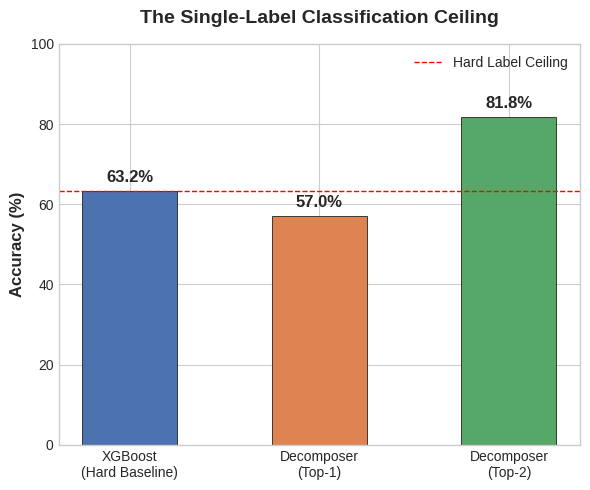

✅ Saved: Slide2_Accuracy_Ceiling.png

Generating Chart 2: Class Distribution...


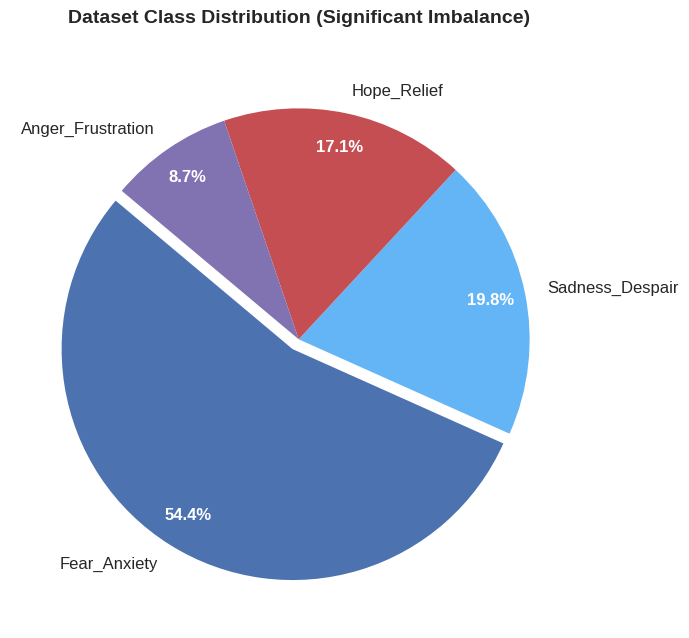

✅ Saved: Slide3_Class_Distribution.png

Generating Chart 3: Purity Analysis...


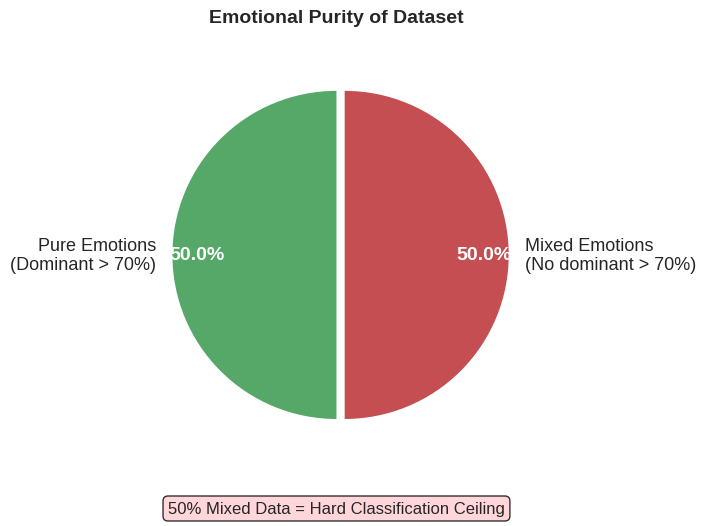

✅ Saved: Slide6_Purity_Analysis.png

🎉 All 3 presentation visuals generated successfully!


In [ ]:
# =========================================================
# SLIDE VISUALS GENERATOR (3 Missing Charts)
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load Data
df = pd.read_csv("/content/final_labeled_PTSD_tweets.csv")

# Set a clean, research-oriented style
plt.style.use('seaborn-v0_8-whitegrid')

# ---------------------------------------------------------
# CHART 1 (For Slide 2): The Hard Classification Ceiling
# ---------------------------------------------------------
print("Generating Chart 1: Accuracy Ceiling...")

fig, ax = plt.subplots(figsize=(6, 5))

# Data
methods = ['XGBoost\n(Hard Baseline)', 'Decomposer\n(Top-1)', 'Decomposer\n(Top-2)']
accuracies = [63.23, 56.97, 81.75]
colors = ['#4C72B0', '#DD8452', '#55A868']

bars = ax.bar(methods, accuracies, color=colors, width=0.5, edgecolor='black', linewidth=0.5)

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylim(0, 100)
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('The Single-Label Classification Ceiling', fontsize=14, fontweight='bold', pad=15)
ax.axhline(y=63.23, color='red', linestyle='--', linewidth=1, label='Hard Label Ceiling')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("/content/Slide2_Accuracy_Ceiling.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: Slide2_Accuracy_Ceiling.png\n")


# ---------------------------------------------------------
# CHART 2 (For Slide 3): Class Distribution Pie Chart
# ---------------------------------------------------------
print("Generating Chart 2: Class Distribution...")

# Count classes (Sorted alphabetically to match mapping)
class_counts = df['final_emotion'].value_counts()
labels = ['Fear_Anxiety', 'Sadness_Despair', 'Hope_Relief', 'Anger_Frustration']
sizes = [class_counts.get(label, 0) for label in labels]
colors_pie = ['#4C72B0', '#64B5F6', '#C44E52', '#8172B2']
explode = (0.05, 0, 0, 0) # Slightly pull out the majority class

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors_pie,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 12},
    pctdistance=0.85
)

# Make percentages bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('Dataset Class Distribution (Significant Imbalance)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("/content/Slide3_Class_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: Slide3_Class_Distribution.png\n")


# ---------------------------------------------------------
# CHART 3 (For Slide 6): Emotional Purity Analysis
# ---------------------------------------------------------
print("Generating Chart 3: Purity Analysis...")

# Data (From our 50% analysis)
purity_labels = ['Pure Emotions\n(Dominant > 70%)', 'Mixed Emotions\n(No dominant > 70%)']
purity_sizes = [50.0, 50.0]
colors_purity = ['#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    purity_sizes,
    labels=purity_labels,
    colors=colors_purity,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 13},
    pctdistance=0.85,
    explode=(0, 0.05) # Pull out the mixed slice
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(14)

ax.set_title('Emotional Purity of Dataset', fontsize=14, fontweight='bold', pad=20)

# Add a text box explaining the impact
textstr = '50% Mixed Data = Hard Classification Ceiling'
props = dict(boxstyle='round', facecolor='#FFCDD2', alpha=0.8)
ax.text(0.5, -0.1, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', ha='center', bbox=props)

plt.tight_layout()
plt.savefig("/content/Slide6_Purity_Analysis.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: Slide6_Purity_Analysis.png\n")

print("🎉 All 3 presentation visuals generated successfully!")